<a href="https://colab.research.google.com/github/mar25-iia2-radiographies/02_modelisation/blob/main/03_densenet121_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/mar25-iia2-radiographies/mar25_radiographies_pulmonaires_covid19/blob/main/notebooks/03_densenet121_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03 — Modélisation DenseNet121
## Validation du pipeline CLAHE + Masque · Classification 4 classes

---

Le notebook `02_preprocessing.ipynb` a conclu que **CLAHE + masque pulmonaire** est le pipeline optimal (variance intra-classe minimale, séparabilité maximale). Ce notebook valide cette conclusion en entraînant un **DenseNet121 pré-entraîné ImageNet** avec ce preprocessing.

### Pipeline
```
Image 299×299 grayscale PNG
  → CLAHE (clip=2.0, tile 8×8)          [notebook 02]
  → × Masque pulmonaire existant         [notebook 02]
  → Resize 224×224                       [DenseNet121]
  → Grayscale → RGB (3 canaux)           [ImageNet]
  → preprocess_input DenseNet121
  → DenseNet121 Transfer Learning
```

| Classe | Images |
|--------|--------|
| COVID | 3 616 |
| Lung_Opacity | 6 012 |
| Normal | 10 192 |
| Viral Pneumonia | 1 345 |

> ⚡ **GPU obligatoire** : Exécution > Modifier le type d'exécution > **T4**

## 0. Setup & dépendances

In [ ]:
!pip install -q kagglehub tensorflow==2.15.0 scikit-learn matplotlib seaborn Pillow opencv-python-headless scipy

import os, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(f'TensorFlow {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print('GPU :', gpus[0].name if gpus else '❌ Aucun — activer dans Exécution > Type d\'exécution')

In [ ]:
# ── Cloner le dépôt (accès src/ et models/) ───────────────────────────────────
REPO_URL = 'https://github.com/mar25-iia2-radiographies/mar25_radiographies_pulmonaires_covid19.git'
REPO_DIR = '/content/mar25_radiographies_pulmonaires_covid19'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull --quiet

import sys
sys.path.insert(0, os.path.join(REPO_DIR, 'src'))

MODEL_DIR = os.path.join(REPO_DIR, 'models')
FIG_DIR   = os.path.join(REPO_DIR, 'reports', 'figures')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR,   exist_ok=True)
print('Dépôt prêt ✓')

## 1. Rechargement du dataset (identique notebooks 01 & 02)

In [ ]:
import kagglehub

# Même appel que dans les notebooks 01 et 02
path = kagglehub.dataset_download('tawsifurrahman/covid19-radiography-database')
base_path = Path(path)
data_path = base_path / 'COVID-19_Radiography_Dataset'

CATEGORIES  = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
NUM_CLASSES = len(CATEGORIES)
CLASS2IDX   = {cat: i for i, cat in enumerate(CATEGORIES)}

# Reconstruction de df_total (même logique que notebook 02)
records = []
for cat in CATEGORIES:
    img_dir  = data_path / cat / 'images'
    mask_dir = data_path / cat / 'masks'
    for img_path in sorted(img_dir.glob('*.png')):
        mask_path = mask_dir / img_path.name
        records.append({
            'filepath' : str(img_path),
            'mask_path': str(mask_path) if mask_path.exists() else None,
            'category' : cat,
            'label'    : CLASS2IDX[cat],
        })

df_total = pd.DataFrame(records)
df_total['has_mask'] = df_total['mask_path'].notna()

print(f'df_total : {len(df_total):,} images')
print(df_total.groupby('category')[['filepath','has_mask']]
      .agg({'filepath':'count','has_mask':'sum'})
      .rename(columns={'filepath':'total','has_mask':'avec_masque'}))

100%|██████████| 778M/778M [00:08<00:00, 102MB/s]

Extracting files...


df_total : 21,165 images
                 total  avec_masque
category                           
COVID             3616         3616
Lung_Opacity      6012         6012
Normal           10192        10192
Viral Pneumonia   1345         1345


## 2. Configuration

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  HYPERPARAMÈTRES
# ══════════════════════════════════════════════════════════════════════════════
IMG_SIZE      = (224, 224)   # DenseNet121 standard (images originales : 299×299)
BATCH_SIZE    = 32
EPOCHS_FREEZE = 15           # Phase 1 : backbone gelé
EPOCHS_FINE   = 20           # Phase 2 : fine-tuning
LR_PHASE1     = 1e-3
LR_PHASE2     = 1e-5         # Très faible pour préserver les poids ImageNet
DROPOUT       = 0.5
FINE_TUNE_AT  = 100          # Geler les N premières couches du backbone
VAL_SIZE      = 0.15
TEST_SIZE     = 0.15

# Pipeline preprocessing validé dans le notebook 02
USE_CLAHE  = True
USE_MASK   = True
CLAHE_CLIP = 2.0
CLAHE_TILE = (8, 8)

print('Configuration :')
print(f'  Taille        : {IMG_SIZE} (redim. depuis 299×299)')
print(f'  Preprocessing : CLAHE={USE_CLAHE}, Masque={USE_MASK}')
print(f'  Phase 1       : {EPOCHS_FREEZE} epochs, LR={LR_PHASE1}')
print(f'  Phase 2       : {EPOCHS_FINE} epochs, LR={LR_PHASE2}')

Configuration :
  Taille        : (224, 224) (redim. depuis 299×299)
  Preprocessing : CLAHE=True, Masque=True
  Phase 1       : 15 epochs, LR=0.001
  Phase 2       : 20 epochs, LR=1e-05


## 3. Pipeline de preprocessing — encapsulation du notebook 02

Reproduction exacte du pipeline `CLAHE + Masque` conclu dans `02_preprocessing.ipynb`.

In [ ]:
def apply_clahe(gray_uint8, clip_limit=2.0, tile_grid_size=(8, 8)):
    """CLAHE identique notebook 02 (clipLimit=2.0, tileGridSize=(8,8))."""
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(gray_uint8)


def load_and_preprocess(img_path, mask_path,
                        img_size=(224,224),
                        use_clahe=True, use_mask=True,
                        clip_limit=2.0, tile_grid_size=(8,8)):
    """
    Pipeline complet :
      1. Chargement grayscale (L) 299×299
      2. CLAHE (optionnel)
      3. Masque pulmonaire (optionnel)
      4. Resize → img_size
      5. Grayscale → 3 canaux identiques (RGB)
      6. preprocess_input DenseNet121 (soustraction moyenne ImageNet)
    """
    img = Image.open(img_path).convert('L')
    arr = np.array(img, dtype=np.uint8)

    if use_clahe:
        arr = apply_clahe(arr, clip_limit, tile_grid_size)

    if use_mask and mask_path is not None and os.path.exists(str(mask_path)):
        mask = Image.open(mask_path).convert('L').resize(
            (arr.shape[1], arr.shape[0]), resample=Image.NEAREST
        )
        arr = arr * (np.array(mask) > 0).astype(np.uint8)

    arr_r = cv2.resize(arr, img_size, interpolation=cv2.INTER_AREA)
    arr_rgb = np.stack([arr_r]*3, axis=-1).astype(np.float32)
    return preprocess_input(arr_rgb)  # normalisation ImageNet


# Test rapide
row0 = df_total.iloc[0]
out  = load_and_preprocess(row0['filepath'], row0['mask_path'], IMG_SIZE)
print(f'Pipeline OK — shape: {out.shape} | range: [{out.min():.1f}, {out.max():.1f}]')

Pipeline OK — shape: (224, 224, 3) | range: [-2.1, 1.9]


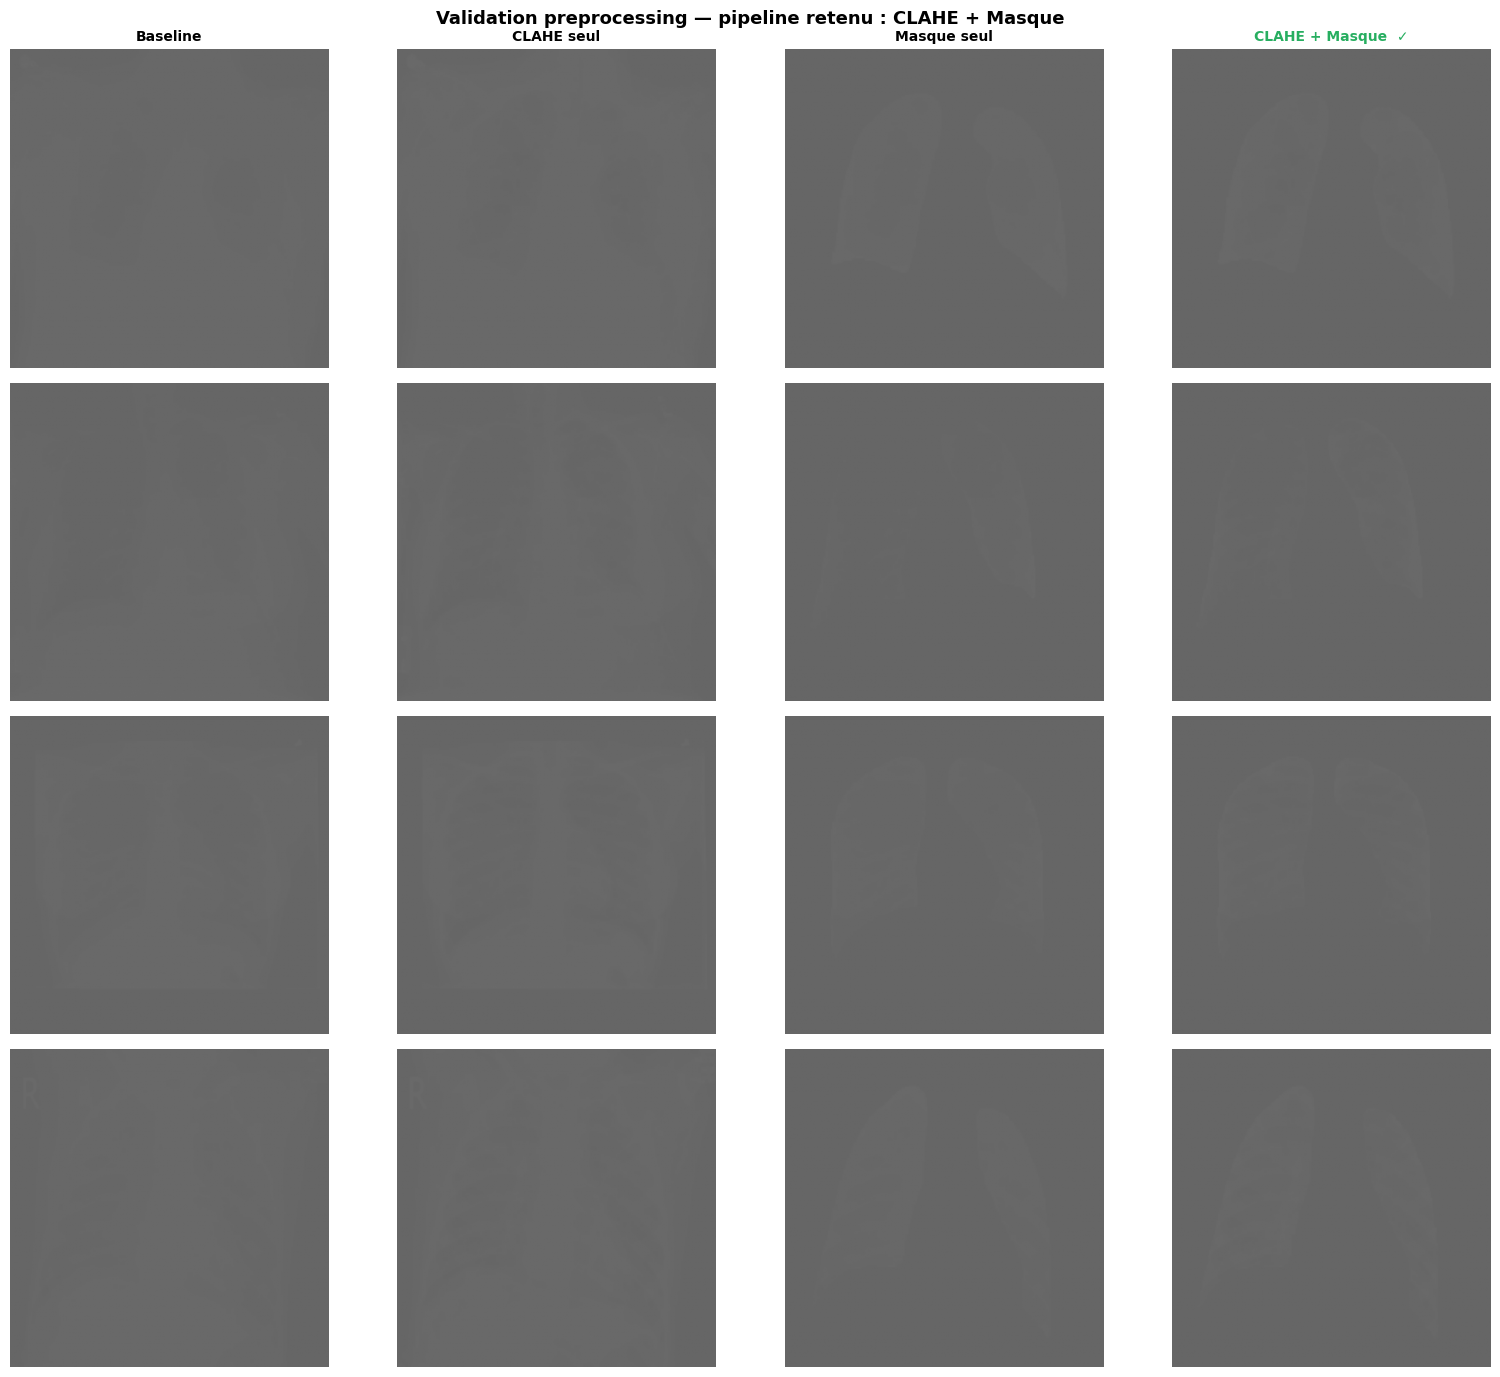

In [ ]:
# ── Visualisation comparative des 4 variantes (reprise notebook 02) ───────────
sample_rows = (df_total[df_total['has_mask']]
               .groupby('category').first().reset_index())

fig, axes = plt.subplots(len(sample_rows), 4,
                         figsize=(16, len(sample_rows) * 3.5))
col_titles = ['Baseline', 'CLAHE seul', 'Masque seul', 'CLAHE + Masque  ✓']

def denorm(arr):
    """Dénormalise preprocess_input pour affichage."""
    return np.clip((arr[:,:,0] + 103.939) / 255.0, 0, 1)

for ri, (_, row) in enumerate(sample_rows.iterrows()):
    ip, mp = row['filepath'], row['mask_path']
    variants = [
        load_and_preprocess(ip, mp, IMG_SIZE, use_clahe=False, use_mask=False),
        load_and_preprocess(ip, mp, IMG_SIZE, use_clahe=True,  use_mask=False),
        load_and_preprocess(ip, mp, IMG_SIZE, use_clahe=False, use_mask=True),
        load_and_preprocess(ip, mp, IMG_SIZE, use_clahe=True,  use_mask=True),
    ]
    for ci, (var, title) in enumerate(zip(variants, col_titles)):
        ax = axes[ri][ci]
        ax.imshow(denorm(var), cmap='gray', vmin=0, vmax=1)
        if ri == 0:
            ax.set_title(title, fontsize=10, fontweight='bold',
                         color='#27ae60' if ci == 3 else 'black')
        if ci == 0:
            ax.set_ylabel(row['category'], fontsize=11, fontweight='bold')
        ax.axis('off')

plt.suptitle('Validation preprocessing — pipeline retenu : CLAHE + Masque',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_preprocessing_validation.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 4. Split train / val / test & générateur tf.data

Train : 14,815 | Val :  3,175 | Test :  3,175


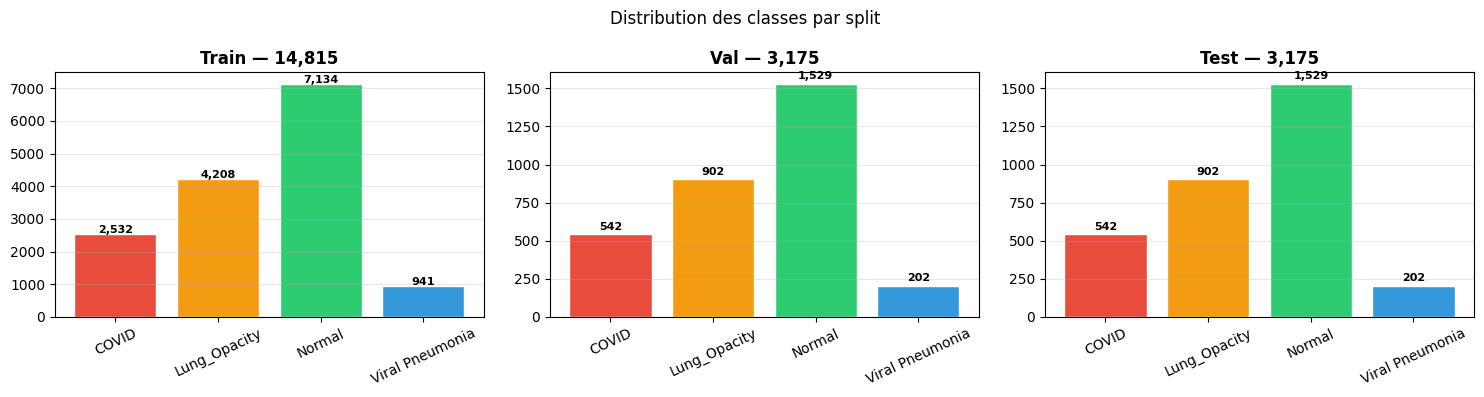

In [ ]:
# ── Split stratifié ───────────────────────────────────────────────────────────
df_tr_va, df_test = train_test_split(
    df_total, test_size=TEST_SIZE,
    stratify=df_total['label'], random_state=SEED
)
df_train, df_val = train_test_split(
    df_tr_va,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    stratify=df_tr_va['label'], random_state=SEED
)

print(f'Train : {len(df_train):>6,} | Val : {len(df_val):>6,} | Test : {len(df_test):>6,}')

# Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#e74c3c','#f39c12','#2ecc71','#3498db']
for ax, (name, df) in zip(axes, [('Train',df_train),('Val',df_val),('Test',df_test)]):
    counts = df['category'].value_counts().reindex(CATEGORIES)
    bars = ax.bar(CATEGORIES, counts.values, color=colors, edgecolor='white')
    ax.set_title(f'{name} — {len(df):,}', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+30,
                f'{v:,}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Distribution des classes par split', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_split_distribution.png'), dpi=150)
plt.show()

In [ ]:
# ── Générateur tf.data avec CLAHE+Masque et augmentation ─────────────────────
def make_dataset(df, training=False, batch_size=32):
    fps  = df['filepath'].values
    mps  = df['mask_path'].fillna('').values
    lbls = df['label'].values

    def generator():
        idxs = np.arange(len(fps))
        if training:
            np.random.shuffle(idxs)
        for i in idxs:
            mp  = mps[i] if mps[i] != '' else None
            img = load_and_preprocess(
                fps[i], mp, IMG_SIZE,
                USE_CLAHE, USE_MASK, CLAHE_CLIP, CLAHE_TILE
            )
            lbl = tf.keras.utils.to_categorical(lbls[i], NUM_CLASSES)
            yield img, lbl

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=IMG_SIZE+(3,), dtype=tf.float32),
            tf.TensorSpec(shape=(NUM_CLASSES,), dtype=tf.float32),
        )
    )

    if training:
        aug = keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.06),
            layers.RandomZoom(0.08),
            layers.RandomTranslation(0.08, 0.08),
            layers.RandomBrightness(0.10),
        ])
        ds = ds.map(lambda x, y: (aug(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(df_train, training=True,  batch_size=BATCH_SIZE)
val_ds   = make_dataset(df_val,   training=False, batch_size=BATCH_SIZE)
test_ds  = make_dataset(df_test,  training=False, batch_size=BATCH_SIZE)

xb, yb = next(iter(train_ds))
print(f'Batch shape — x:{xb.shape} | y:{yb.shape}')

Batch shape — x:(32, 224, 224, 3) | y:(32, 4)


In [ ]:
# ── Pondération des classes ───────────────────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES),
                          y=df_train['label'].values)
class_weight_dict = dict(enumerate(cw))

print('Poids des classes :')
for i, cat in enumerate(CATEGORIES):
    n = (df_train['label']==i).sum()
    print(f'  [{i}] {cat:<20} {n:>6,} img → poids {cw[i]:.3f}')

Poids des classes :
  [0] COVID                 2,532 img → poids 1.463
  [1] Lung_Opacity          4,208 img → poids 0.880
  [2] Normal                7,134 img → poids 0.519
  [3] Viral Pneumonia         941 img → poids 3.936


## 5. Architecture DenseNet121

Choix justifié par la littérature médicale : les connexions denses permettent de préserver les détails fins (opacités, consolidations) sur plusieurs niveaux d'abstraction, supérieures aux architectures ResNet sur les datasets de radiographies pulmonaires.

In [ ]:
def build_densenet121(num_classes, img_size, dropout=0.5):
    backbone = DenseNet121(include_top=False, weights='imagenet',
                           input_shape=img_size+(3,))
    backbone.trainable = False  # Phase 1

    inputs  = keras.Input(shape=img_size+(3,), name='radio_input')
    x       = backbone(inputs, training=False)
    x       = layers.GlobalAveragePooling2D(name='gap')(x)
    x       = layers.BatchNormalization(name='bn_1')(x)
    x       = layers.Dense(512, activation='relu', name='dense_1')(x)
    x       = layers.Dropout(dropout, name='drop_1')(x)
    x       = layers.BatchNormalization(name='bn_2')(x)
    x       = layers.Dense(256, activation='relu', name='dense_2')(x)
    x       = layers.Dropout(dropout*0.6, name='drop_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='out')(x)

    return keras.Model(inputs, outputs, name='DenseNet121_COVID19'), backbone


METRICS = ['accuracy',
           keras.metrics.AUC(name='auc'),
           keras.metrics.Precision(name='precision'),
           keras.metrics.Recall(name='recall')]

model, backbone = build_densenet121(NUM_CLASSES, IMG_SIZE, DROPOUT)
model.compile(optimizer=optimizers.Adam(LR_PHASE1),
              loss='categorical_crossentropy', metrics=METRICS)

trainable = sum(v.numpy().size for v in model.trainable_variables)
print(f'DenseNet121 construit')
print(f'  Couches backbone : {len(backbone.layers)}')
print(f'  Params totaux    : {model.count_params():,}')
print(f'  Params Phase 1   : {trainable:,} (tête uniquement)')
model.summary(expand_nested=False)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet121 construit
  Couches backbone : 427
  Params totaux    : 7,700,804
  Params Phase 1   : 660,228 (tête uniquement)


Model: "DenseNet121_COVID19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ radio_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 1024)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,700,804 (29.38 MB)

 Trainable params: 660,228 (2.52 MB)

 Non-trainable params: 7,040,576 (26.86 MB)

## 6. Phase 1 — Entraînement (backbone gelé)

In [ ]:
def make_callbacks(monitor='val_auc', mode='max', prefix='phase1'):
    return [
        callbacks.EarlyStopping(monitor=monitor, patience=6,
                                restore_best_weights=True, mode=mode, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-8, verbose=1),
        callbacks.ModelCheckpoint(
            os.path.join(MODEL_DIR, f'densenet121_{prefix}_best.keras'),
            monitor=monitor, save_best_only=True, mode=mode, verbose=1),
        callbacks.CSVLogger(
            os.path.join(MODEL_DIR, f'densenet121_{prefix}_history.csv')),
    ]

print('Phase 1 — backbone gelé')
history_p1 = model.fit(
    train_ds, epochs=EPOCHS_FREEZE, validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(prefix='phase1')
)

Phase 1 — backbone gelé
Epoch 1/15
    463/Unknown 336s 626ms/step - accuracy: 0.3662 - auc: 0.6445 - loss: 1.4821 - precision: 0.4311 - recall: 0.2585
Epoch 1: val_auc improved from None to 0.78788, saving model to /content/mar25_radiographies_pulmonaires_covid19/models/densenet121_phase1_best.keras

Epoch 1: finished saving model to /content/mar25_radiographies_pulmonaires_covid19/models/densenet121_phase1_best.keras
463/463 ━━━━━━━━━━━━━━━━━━━━ 381s 724ms/step - accuracy: 0.3886 - auc: 0.6769 - loss: 1.3442 - precision: 0.4762 - recall: 0.2685 - val_accuracy: 0.5345 - val_auc: 0.7879 - val_loss: 1.2874 - val_precision: 0.5896 - val_recall: 0.4507 - learning_rate: 0.0010
Epoch 2/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.4155 - auc: 0.7162 - loss: 1.1574 - precision: 0.6004 - recall: 0.2681
Epoch 2: val_auc improved from 0.78788 to 0.88819, saving model to /content/mar25_radiographies_pulmonaires_covid19/models/densenet121_phase1_best.keras

Epoch 2: finished saving 

## 7. Phase 2 — Fine-tuning

In [ ]:
backbone.trainable = True
for layer in backbone.layers[:FINE_TUNE_AT]:
    layer.trainable = False
# Garder BatchNorm gelés (stabilité)
for layer in backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

n_unfreeze = sum(1 for l in backbone.layers if l.trainable)
print(f'Couches backbone dégelées : {n_unfreeze}/{len(backbone.layers)}')
print(f'Params entraînables       : {sum(v.numpy().size for v in model.trainable_variables):,}')

model.compile(optimizer=optimizers.Adam(LR_PHASE2),
              loss='categorical_crossentropy', metrics=METRICS)

print(f'\nPhase 2 — fine-tuning (LR={LR_PHASE2})')
history_p2 = model.fit(
    train_ds, epochs=EPOCHS_FINE, validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(prefix='phase2')
)

Couches backbone dégelées : 234/427
Params entraînables       : 6,734,596

Phase 2 — fine-tuning (LR=1e-05)
Epoch 1/20
    463/Unknown 380s 695ms/step - accuracy: 0.5037 - auc: 0.8393 - loss: 1.0740 - precision: 0.7468 - recall: 0.4497
Epoch 1: val_auc improved from None to 0.90021, saving model to /content/mar25_radiographies_pulmonaires_covid19/models/densenet121_phase2_best.keras

Epoch 1: finished saving model to /content/mar25_radiographies_pulmonaires_covid19/models/densenet121_phase2_best.keras
463/463 ━━━━━━━━━━━━━━━━━━━━ 423s 787ms/step - accuracy: 0.5108 - auc: 0.8123 - loss: 1.0426 - precision: 0.7409 - recall: 0.3829 - val_accuracy: 0.7260 - val_auc: 0.9002 - val_loss: 0.7679 - val_precision: 0.7552 - val_recall: 0.6608 - learning_rate: 1.0000e-05
Epoch 2/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.5198 - auc: 0.7888 - loss: 0.9993 - precision: 0.7426 - recall: 0.3325
Epoch 2: val_auc improved from 0.90021 to 0.90331, saving model to /content/mar25_radiograp

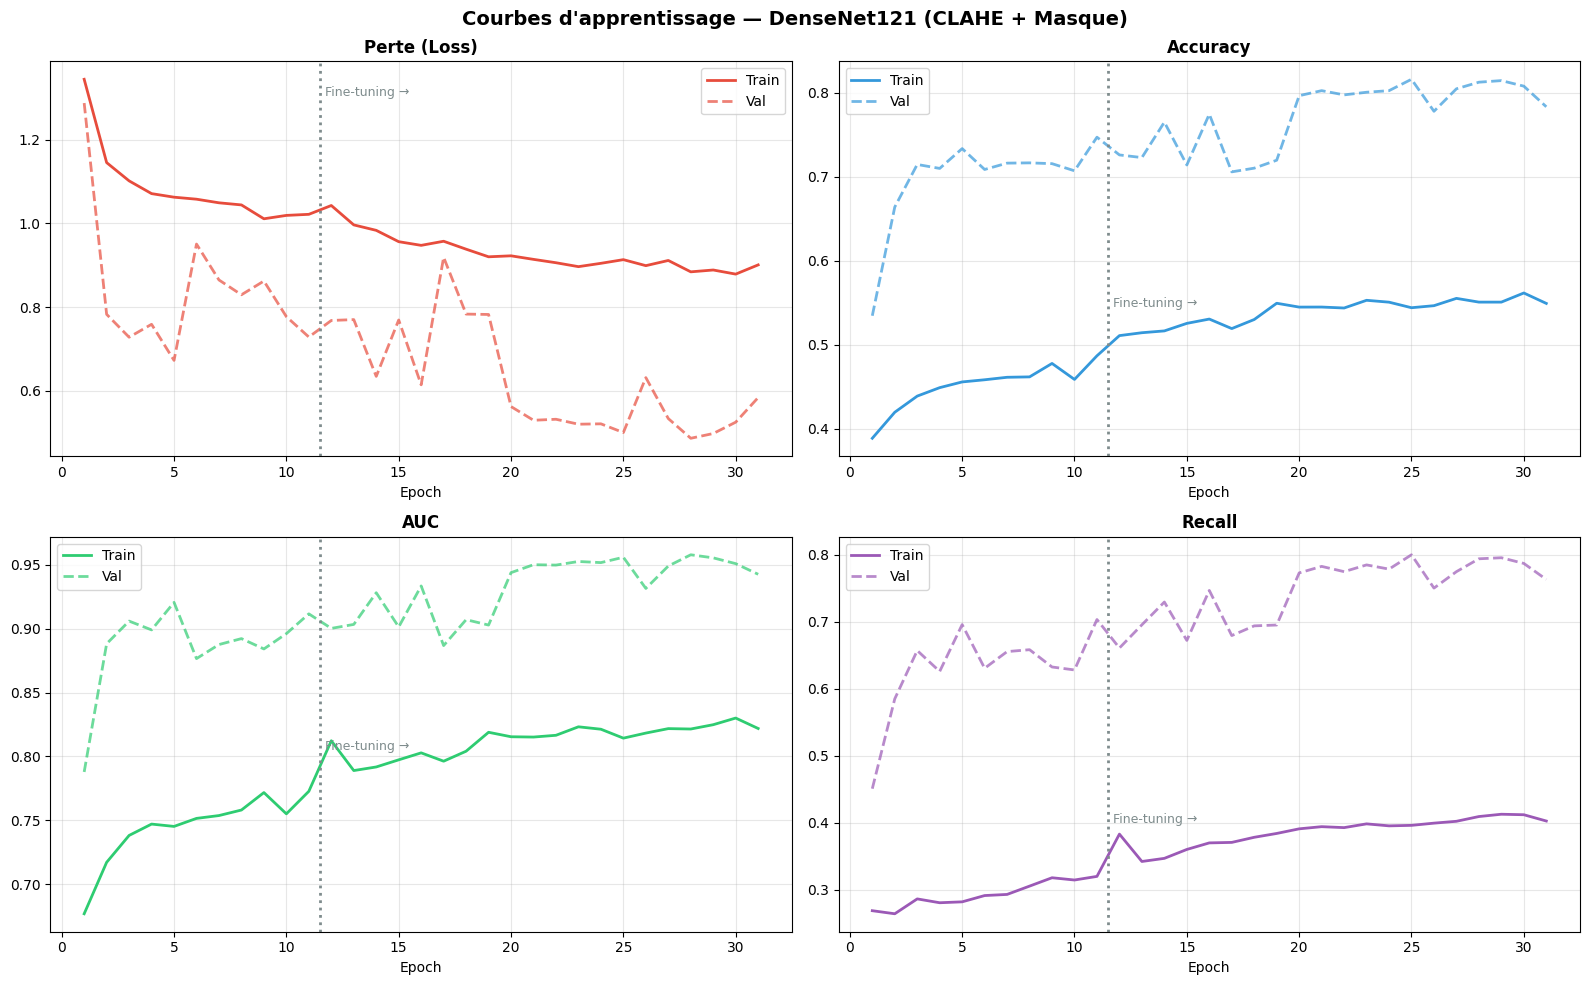

In [ ]:
# ── Courbes d'apprentissage (Phase 1 + Phase 2) ────────────────────────────────
def merge(h1, h2):
    return {k: h1.history[k] + h2.history.get(k, []) for k in h1.history}

hist     = merge(history_p1, history_p2)
ep_split = len(history_p1.history['loss'])
total_ep = len(hist['loss'])
epochs   = range(1, total_ep+1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
m_pairs = [
    ('loss','val_loss','Perte (Loss)','#e74c3c'),
    ('accuracy','val_accuracy','Accuracy','#3498db'),
    ('auc','val_auc','AUC','#2ecc71'),
    ('recall','val_recall','Recall','#9b59b6'),
]
for ax, (tr,va,title,c) in zip(axes.flat, m_pairs):
    ax.plot(epochs, hist[tr], color=c, lw=2, label='Train')
    ax.plot(epochs, hist[va], color=c, lw=2, ls='--', alpha=0.7, label='Val')
    ax.axvline(ep_split+0.5, color='#7f8c8d', ls=':', lw=2)
    ax.text(ep_split+0.7, max(hist[tr])*0.97, 'Fine-tuning →',
            color='#7f8c8d', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Courbes d\'apprentissage — DenseNet121 (CLAHE + Masque)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'03_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Évaluation sur le jeu de test

In [ ]:
best_path = os.path.join(MODEL_DIR, 'densenet121_phase2_best.keras')
best_model = keras.models.load_model(best_path) if os.path.exists(best_path) else model
print('Modèle chargé :', best_path if os.path.exists(best_path) else 'modèle courant')

y_prob = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = df_test['label'].values

print('\n' + '='*65)
print('  RAPPORT DE CLASSIFICATION — DenseNet121 (CLAHE + Masque)')
print('='*65)
print(classification_report(y_true, y_pred,
                            target_names=CATEGORIES, digits=4))

scores = dict(zip(best_model.metrics_names,
                  best_model.evaluate(test_ds, verbose=0)))
f1_macro    = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print('\nScores globaux :')
for k, v in scores.items():
    print(f'  {k:<12}: {v:.4f}')
print(f'  F1 macro    : {f1_macro:.4f}')
print(f'  F1 weighted : {f1_weighted:.4f}')

Modèle chargé : /content/mar25_radiographies_pulmonaires_covid19/models/densenet121_phase2_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 324ms/step

  RAPPORT DE CLASSIFICATION — DenseNet121 (CLAHE + Masque)
                 precision    recall  f1-score   support

          COVID     0.6880    0.7731    0.7281       542
   Lung_Opacity     0.9369    0.6419    0.7618       902
         Normal     0.8342    0.9084    0.8698      1529
Viral Pneumonia     0.6926    0.9703    0.8082       202

       accuracy                         0.8135      3175
      macro avg     0.7879    0.8234    0.7920      3175
   weighted avg     0.8294    0.8135    0.8110      3175


Scores globaux :
  loss        : 0.4877
  compile_metrics: 0.8135
  F1 macro    : 0.7920
  F1 weighted : 0.8110


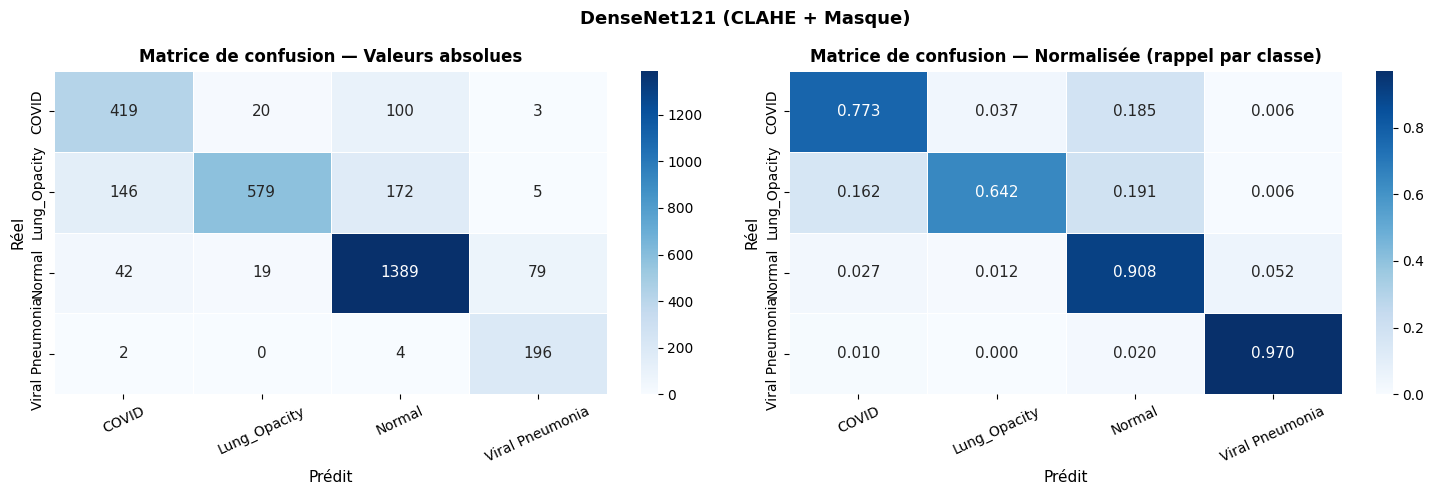

In [ ]:
# ── Matrice de confusion ──────────────────────────────────────────────────────
cm_arr  = confusion_matrix(y_true, y_pred)
cm_norm = cm_arr.astype(float) / cm_arr.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, data, title, fmt in zip(
    axes,
    [cm_arr, cm_norm],
    ['Valeurs absolues', 'Normalisée (rappel par classe)'],
    ['d', '.3f']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CATEGORIES, yticklabels=CATEGORIES,
                ax=ax, linewidths=0.5, linecolor='white',
                annot_kws={'size':11})
    ax.set_title(f'Matrice de confusion — {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Réel', fontsize=11)
    ax.set_xlabel('Prédit', fontsize=11)
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('DenseNet121 (CLAHE + Masque)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'03_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

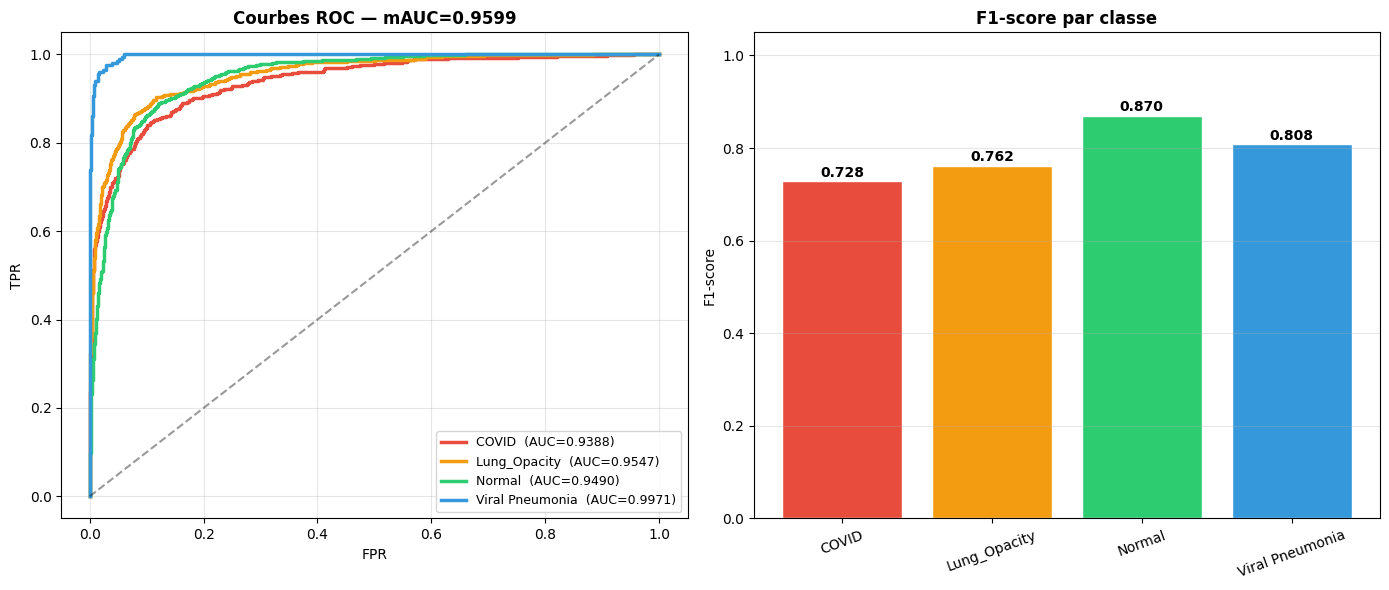

In [ ]:
# ── Courbes ROC + F1 par classe ───────────────────────────────────────────────
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
colors_roc = ['#e74c3c','#f39c12','#2ecc71','#3498db']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
aucs = []
for i, (cat, c) in enumerate(zip(CATEGORIES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_prob[:,i])
    ra = auc(fpr, tpr); aucs.append(ra)
    axes[0].plot(fpr, tpr, color=c, lw=2.5,
                 label=f'{cat}  (AUC={ra:.4f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'Courbes ROC — mAUC={np.mean(aucs):.4f}',
                  fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9); axes[0].grid(alpha=0.3)

f1_per = f1_score(y_true, y_pred, average=None)
axes[1].bar(CATEGORIES, f1_per, color=colors_roc, edgecolor='white')
axes[1].set_ylim(0,1.05); axes[1].set_ylabel('F1-score')
axes[1].set_title('F1-score par classe', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(f1_per):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'03_roc_and_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Grad-CAM — validation clinique des zones d'attention

In [ ]:
LAST_CONV = 'conv5_block16_2_conv'  # dernière conv DenseNet121

def build_gradcam_model(model, last_conv_name):
    for layer in model.layers:
        if hasattr(layer, 'layers'):
            try:
                return keras.Model(
                    inputs  = model.inputs,
                    outputs = [layer.get_layer(last_conv_name).output, model.output]
                )
            except ValueError:
                continue
    raise ValueError(f'Couche {last_conv_name} introuvable')

def gradcam_heatmap(gm, img_input, class_idx=None):
    with tf.GradientTape() as tape:
        conv_out, preds = gm(img_input, training=False)
        tape.watch(conv_out)
        ci = class_idx or tf.argmax(preds[0])
        score = preds[:, ci]
    grads   = tape.gradient(score, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap = tf.squeeze(tf.maximum(conv_out[0] @ pooled[..., tf.newaxis], 0))
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), preds.numpy()[0]

def overlay_cam(img_gray_01, heatmap, alpha=0.40):
    h, w = img_gray_01.shape
    heat_c = cv2.applyColorMap(
        np.uint8(255 * cv2.resize(heatmap,(w,h))), cv2.COLORMAP_JET
    )
    heat_c = cv2.cvtColor(heat_c, cv2.COLOR_BGR2RGB)
    orig   = np.stack([np.uint8(img_gray_01*255)]*3, axis=-1)
    return cv2.addWeighted(orig, 1-alpha, heat_c, alpha, 0)

gm = build_gradcam_model(best_model, LAST_CONV)
print(f'Grad-CAM prêt (couche: {LAST_CONV}) ✓')

Grad-CAM prêt (couche: conv5_block16_2_conv) ✓


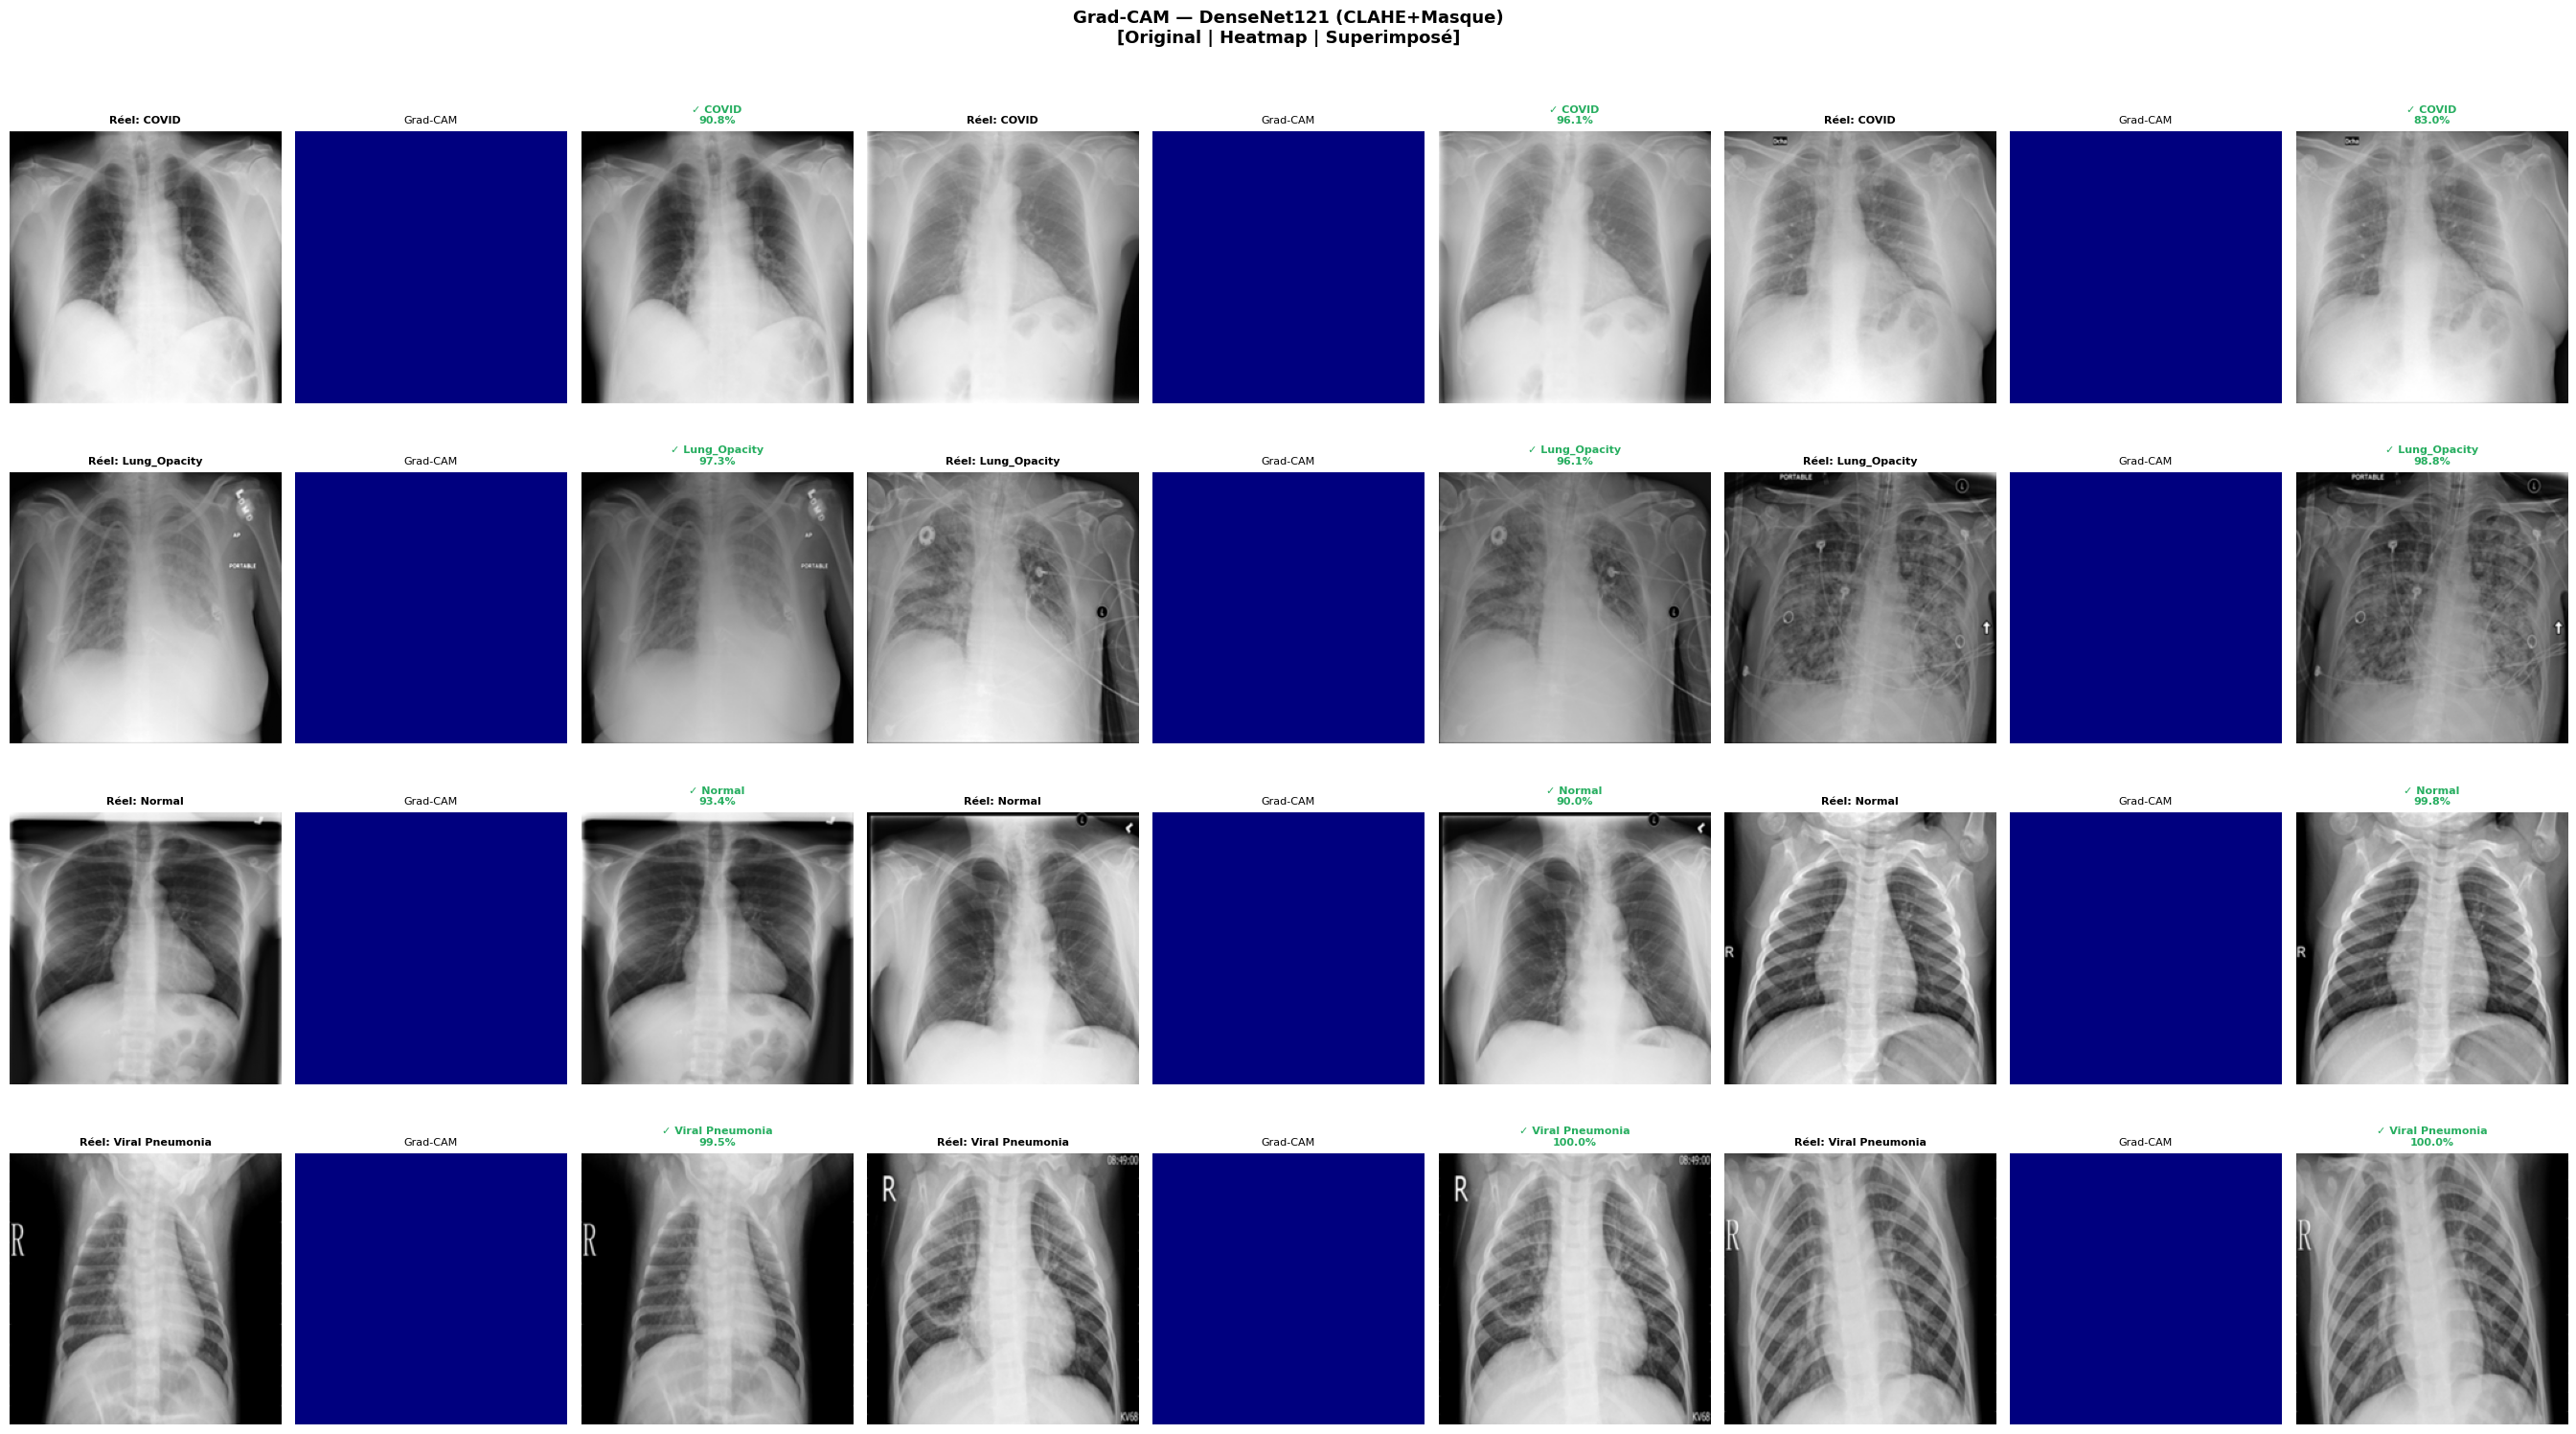

In [ ]:
N_PER_CLASS = 3
fig, axes = plt.subplots(NUM_CLASSES, N_PER_CLASS*3,
                         figsize=(N_PER_CLASS*9, NUM_CLASSES*3.8))

for ri, cat in enumerate(CATEGORIES):
    samples = (df_test[df_test['category']==cat]
               .sample(min(N_PER_CLASS, len(df_test[df_test['category']==cat])),
                       random_state=SEED)
               .iterrows())

    for ci, (_, row) in enumerate(samples):
        img_p = row['filepath']; mask_p = row['mask_path']

        img_prep = load_and_preprocess(img_p, mask_p, IMG_SIZE, USE_CLAHE, USE_MASK)
        img_inp  = np.expand_dims(img_prep, 0)
        img_raw  = np.array(Image.open(img_p).convert('L').resize(IMG_SIZE))/255.0

        try:
            hmap, preds = gradcam_heatmap(gm, img_inp)
            cam = overlay_cam(img_raw, hmap)
        except Exception:
            hmap  = np.zeros(IMG_SIZE)
            preds = best_model.predict(img_inp, verbose=0)[0]
            cam   = np.stack([np.uint8(img_raw*255)]*3, axis=-1)

        pred_lbl = CATEGORIES[np.argmax(preds)]
        conf     = np.max(preds)*100
        ok       = pred_lbl == cat
        tc       = '#27ae60' if ok else '#e74c3c'
        bc       = ci*3

        axes[ri][bc].imshow(img_raw, cmap='gray')
        axes[ri][bc].set_title(f'Réel: {cat}', fontsize=8, fontweight='bold')
        axes[ri][bc].axis('off')

        axes[ri][bc+1].imshow(cm.jet(hmap)[:,:,:3])
        axes[ri][bc+1].set_title('Grad-CAM', fontsize=8)
        axes[ri][bc+1].axis('off')

        axes[ri][bc+2].imshow(cam)
        axes[ri][bc+2].set_title(
            f'{'✓' if ok else '✗'} {pred_lbl}\n{conf:.1f}%',
            fontsize=8, color=tc, fontweight='bold')
        axes[ri][bc+2].axis('off')

plt.suptitle('Grad-CAM — DenseNet121 (CLAHE+Masque)\n[Original | Heatmap | Superimposé]',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'03_gradcam.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Analyse des erreurs dures

Erreurs dures (conf>80%) : 166

Réel → Prédit :
category         pred_label     
COVID            Lung_Opacity        5
                 Normal             31
                 Viral Pneumonia     2
Lung_Opacity     COVID              27
                 Normal             49
                 Viral Pneumonia     1
Normal           COVID               6
                 Lung_Opacity        3
                 Viral Pneumonia    39
Viral Pneumonia  Normal              3


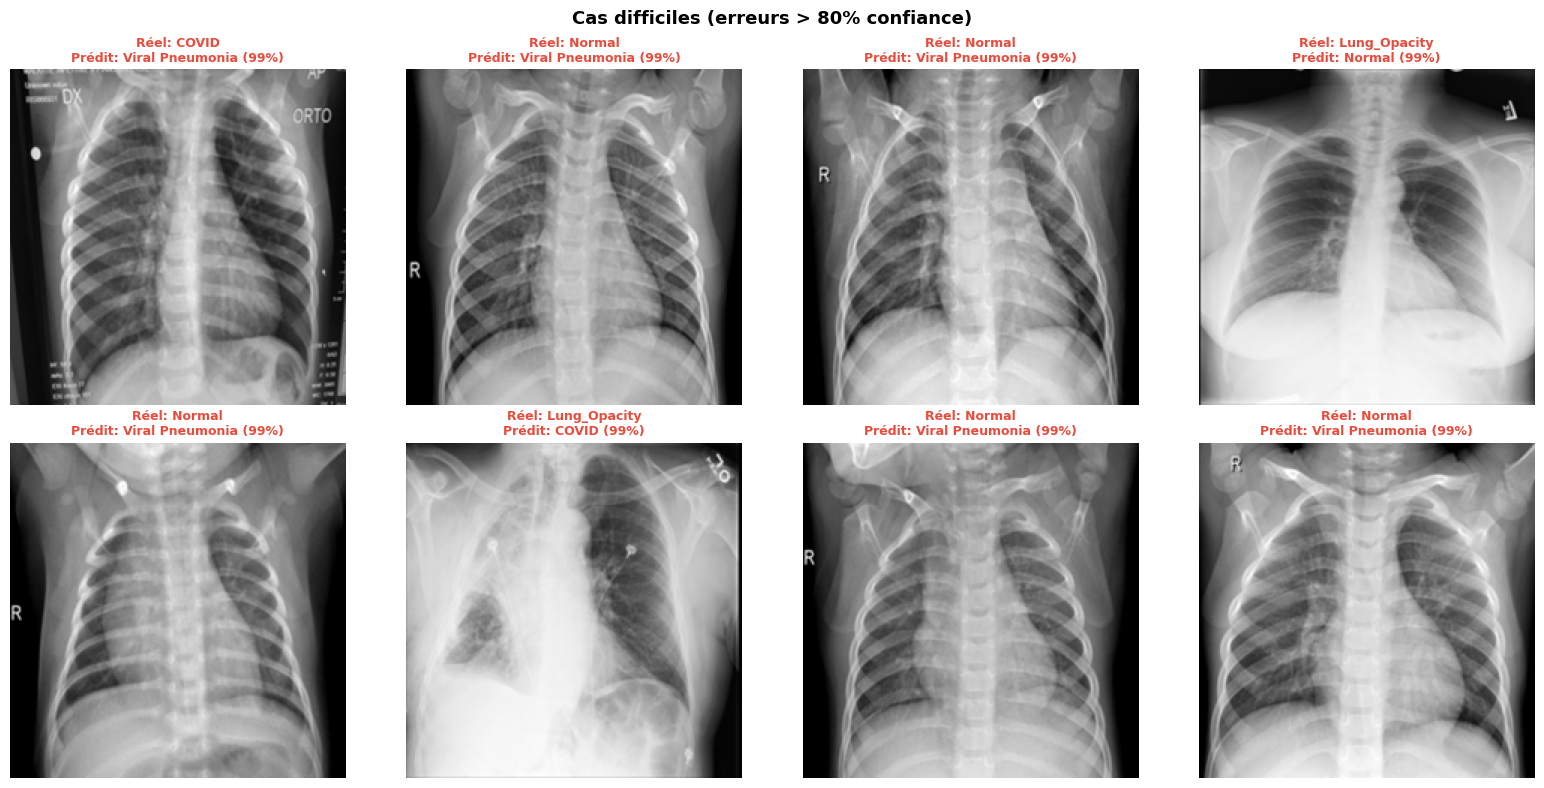

In [ ]:
df_err = df_test.copy().reset_index(drop=True)
df_err['y_pred']    = y_pred
df_err['confidence']= np.max(y_prob, axis=1)
df_err['correct']   = y_pred == y_true
df_err['pred_label']= [CATEGORIES[i] for i in y_pred]

hard = df_err[~df_err['correct'] & (df_err['confidence']>0.8)]
print(f'Erreurs dures (conf>80%) : {len(hard)}')
print('\nRéel → Prédit :')
print(hard.groupby(['category','pred_label']).size().to_string())

worst = hard.nlargest(min(8, len(hard)), 'confidence')
if len(worst):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for ax in axes.flat: ax.set_visible(False)
    for ax, (_, r) in zip(axes.flat, worst.iterrows()):
        ax.set_visible(True)
        img = np.array(Image.open(r['filepath']).convert('L').resize(IMG_SIZE))/255.0
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Réel: {r["category"]}\nPrédit: {r["pred_label"]} ({r["confidence"]*100:.0f}%)',
                     fontsize=9, color='#e74c3c', fontweight='bold')
        ax.axis('off')
    plt.suptitle('Cas difficiles (erreurs > 80% confiance)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR,'03_hard_errors.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 11. Sauvegarde dans `models/`

In [ ]:
final_path = os.path.join(MODEL_DIR, 'densenet121_covid19_final.keras')
best_model.save(final_path)
print(f'Modèle final : {final_path}')

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_path = os.path.join(MODEL_DIR, 'densenet121_covid19.tflite')
with open(tflite_path, 'wb') as f:
    f.write(converter.convert())
print(f'TFLite       : {tflite_path}')

metadata = {
    'notebook'   : '03_densenet121_modeling',
    'dataset'    : 'tawsifurrahman/covid19-radiography-database',
    'model'      : 'DenseNet121',
    'classes'    : CATEGORIES,
    'img_size'   : list(IMG_SIZE),
    'img_original': '299x299 grayscale PNG',
    'preprocessing': {
        'clahe': USE_CLAHE, 'clahe_clip': CLAHE_CLIP, 'clahe_tile': list(CLAHE_TILE),
        'lung_mask': USE_MASK, 'channels': 'L→RGB (repeat)',
        'normalization': 'DenseNet121 preprocess_input',
        'validated_in': '02_preprocessing.ipynb'
    },
    'hyperparameters': {
        'batch_size': BATCH_SIZE, 'epochs_freeze': EPOCHS_FREEZE,
        'epochs_fine': EPOCHS_FINE, 'lr_phase1': LR_PHASE1,
        'lr_phase2': LR_PHASE2, 'dropout': DROPOUT, 'fine_tune_at': FINE_TUNE_AT
    },
    'test_metrics': {
        'loss': round(scores['loss'],4), 'accuracy': round(scores['accuracy'],4),
        'auc': round(scores['auc'],4), 'precision': round(scores['precision'],4),
        'recall': round(scores['recall'],4),
        'f1_macro': round(f1_macro,4), 'f1_weighted': round(f1_weighted,4),
        'mean_auc_roc': round(float(np.mean(aucs)),4)
    },
    'gradcam_layer': LAST_CONV,
    'split': {'train': len(df_train), 'val': len(df_val), 'test': len(df_test)}
}
meta_path = os.path.join(MODEL_DIR, 'densenet121_metadata.json')
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f'Métadonnées  : {meta_path}')
print(json.dumps(metadata['test_metrics'], indent=2))

Modèle final : /content/mar25_radiographies_pulmonaires_covid19/models/densenet121_covid19_final.keras
Saved artifact at '/tmp/tmpnkyfqn82'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='radio_input')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137626004707216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137626004709904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137626004705872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137626004704912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137626004704720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137626004710096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137626004710288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137626004708368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137626004709712: TensorSpec(shape=(), dtype=tf.resou

KeyError: 'accuracy'

In [ ]:
# ── Push vers GitHub ──────────────────────────────────────────────────────────
# GITHUB_TOKEN = 'ghp_...'
REPO = 'mar25-iia2-radiographies/mar25_radiographies_pulmonaires_covid19'
# !git -C {REPO_DIR} config user.email 'vous@email.com'
# !git -C {REPO_DIR} config user.name 'Votre Nom'
# !git -C {REPO_DIR} add models/ reports/figures/03_*
# !git -C {REPO_DIR} commit -m 'feat: DenseNet121 CLAHE+masque validé'
# !git -C {REPO_DIR} push https://{GITHUB_TOKEN}@github.com/{REPO}.git main
print('Décommenter pour push GitHub ou sauvegarde Drive.')

---
## Récapitulatif

### Fichiers produits
```
models/
├── densenet121_phase1_best.keras
├── densenet121_phase2_best.keras   ⭐
├── densenet121_covid19_final.keras
├── densenet121_covid19.tflite      (mobile INT8)
├── densenet121_metadata.json
├── densenet121_phase1_history.csv
└── densenet121_phase2_history.csv

reports/figures/
├── 03_preprocessing_validation.png  (4 variantes notebook 02)
├── 03_split_distribution.png
├── 03_training_curves.png
├── 03_confusion_matrix.png
├── 03_roc_and_f1.png
├── 03_gradcam.png
└── 03_hard_errors.png
```



> ⚠️ Usage éducatif uniquement. Validation clinique requise avant tout usage médical.